In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


data = np.genfromtxt(
    "PS_2026.04.21_03.28.15.csv",
    delimiter=",",
    comments="#",
    dtype=float,
    filling_values=np.nan
)


data = np.delete(data, [1,2,3,7,9,10,11], axis=1) #delete errors and limit flag

data1 = []

for n in range(len(data)):
    if (np.isnan(data[n,:]).any() == False):
        data1.append(data[n, :])

data1 = np.array(data1)
data2  = np.array(data1)

for n in range(len(data2)):
    data2[n,2] = (data2[n,2] - data2[n,3])/2 #take the mean of the 2 errors

sample_a = np.delete(data2,3, axis = 1)

In [2]:
print("number of planets in the dataset: ", len(sample_a))

number of planets in the dataset:  2914


In [3]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [4]:
sample_b = []
for n in range(len(sample_a)):
    if (sample_a[n,0] <= 5):
        sample_b.append(sample_a[n,0])
sample_b = np.array(sample_b)

In [5]:
print("number of planets in sample b: ", len(sample_b))

number of planets in sample b:  1145


Text(0, 0.5, 'planetary mass [Earth Mass]')

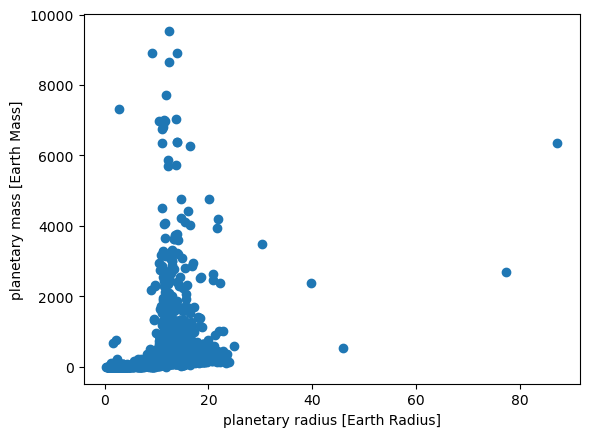

In [6]:
plt.scatter(sample_a[:,0], sample_a[:,1])
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [7]:
planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
error_m = sample_a[:, 2].copy()
stellar_m = sample_a[:, 3].copy()

# log Transformation
log_planet_r = np.log(planet_r)
log_stellar_m = np.log(stellar_m)
log_planet_m = np.log(planet_m)
log_error_m = error_m / (planet_m) # relative error (we can't just apply logarithmic transformation to the error)

log_sample_a = np.column_stack((log_planet_r, log_planet_m, log_error_m, log_stellar_m))

In [8]:
(sample_a[:,1] == data2[:,1]).all()

np.True_

In [9]:
(log_sample_a[:,3] == log_error_m).all()

np.False_

In [10]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

Text(0, 0.5, 'planetary mass [Earth Mass]')

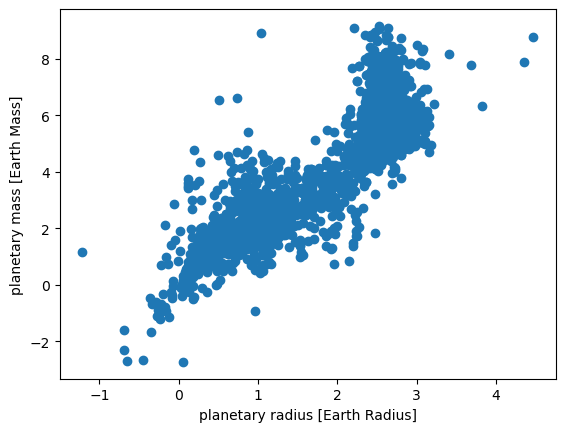

In [11]:
plt.scatter(log_sample_a[:,0], log_sample_a[:,1])
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [47]:
#derive log sample_b:

log_sample_b = []
for n in range(len(log_sample_a)):
    if (log_sample_a[n,0] <= np.log(5)):
        log_sample_b.append(log_sample_a[n,:])
log_sample_b = np.array(log_sample_b)

In [48]:
np.shape(log_sample_b)

(1145, 4)

## Linear Regression

Ignoring the uncertainties associated with the mass measurements, use a 1D linear regression model
to fit sample_B:

Text(0, 0.5, 'planetary mass [Earth Mass]')

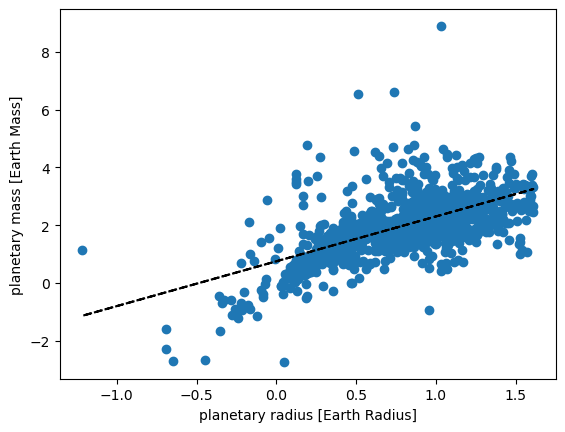

In [49]:
a,b = np.polyfit(log_sample_b[:,0], log_sample_b[:,1], 1)
poly1d_fn = np.poly1d((a,b)) #since we are in log space it makes sense to use an intercept
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(log_sample_b[:,0], log_sample_b[:,1],"o", log_sample_b[:,0], poly1d_fn(log_sample_b[:,0]), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [54]:
solar_planets = np.array([[2439.4, 0.330103e24, 0.000021e24],   #mean radius (because I think it says more about mass
                          [6051.8, 4.86731e24, 0.00023e24],
                          [6371.0084, 5.97217e24, 0.00028e24],
                          [3389.50, 0.641691e24, 0.000030e24],
                          [69911, 1898.125e24, 0.088e24],
                          [58232, 568.317e24, 0.026e24],
                          [25362, 86.8099e24, 0.0040e24],
                          [24622, 102.4092e24, 0.0048e24]])

solar_planets[:,0] = solar_planets[:,0] / 6378 #converting radius km -> earth radius
solar_planets[:,1] = solar_planets[:,1] /5.972e+24
solar_planets[:,2] = solar_planets[:,2] /5.972e+24

solarplanet_r = solar_planets[:, 0].copy() #apply logarithmic transformation
solarplanet_m = solar_planets[:, 1].copy()
solarerror_m = solar_planets[:, 2].copy()


# log Transformation
log_solarplanet_r = np.log(solarplanet_r)
log_solarplanet_m = np.log(solarplanet_m)
log_solarerror_m = solarerror_m / (solarplanet_m) # relative error (we can't just apply logarithmic transformation to the error)

log_solar_planets = np.column_stack((log_solarplanet_r,log_solarplanet_m, log_solarerror_m))


In [ ]:
# Notiz: auf sample a gefittet, werden die planeten besser approximiert!

Text(0, 0.5, 'planetary mass of solar planets [Earth Mass]')

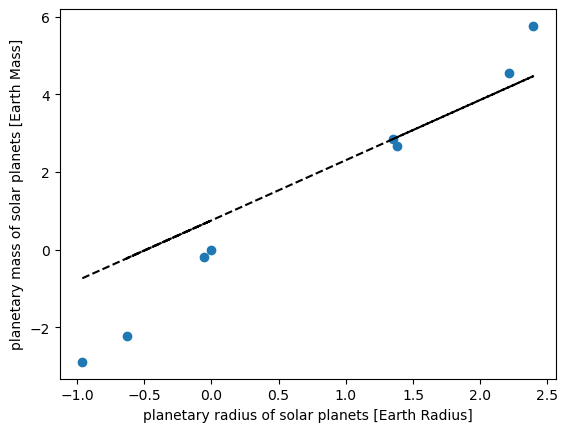

In [55]:
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(log_solarplanet_r,log_solarplanet_m,"o", log_solarplanet_r, poly1d_fn(log_solarplanet_r), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius of solar planets [Earth Radius]')
plt.ylabel('planetary mass of solar planets [Earth Mass]')

In [57]:
def linear_model(x, a, b):
    return a * x + b

popt, pcov = curve_fit(
    linear_model,
    log_sample_b[:,0],
    log_sample_b[:,1],
    sigma=log_sample_b[:,2],
    absolute_sigma=True
)

a_3, b_3 = popt

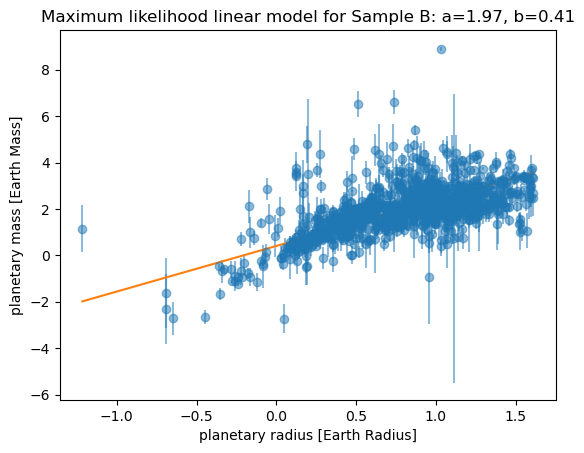

In [59]:
x_fit = np.linspace(min(log_sample_b[:,0]), max(log_sample_b[:,0]), 100)
y_fit = linear_model(x_fit, a_3, b_3)

plt.errorbar(log_sample_b[:,0], log_sample_b[:,1], yerr=log_sample_b[:,2], fmt='o', alpha=0.5)
plt.plot(x_fit, y_fit)

plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.title(f"Maximum likelihood linear model for Sample B: a={a_3:.2f}, b={b_3:.2f}")
plt.show()

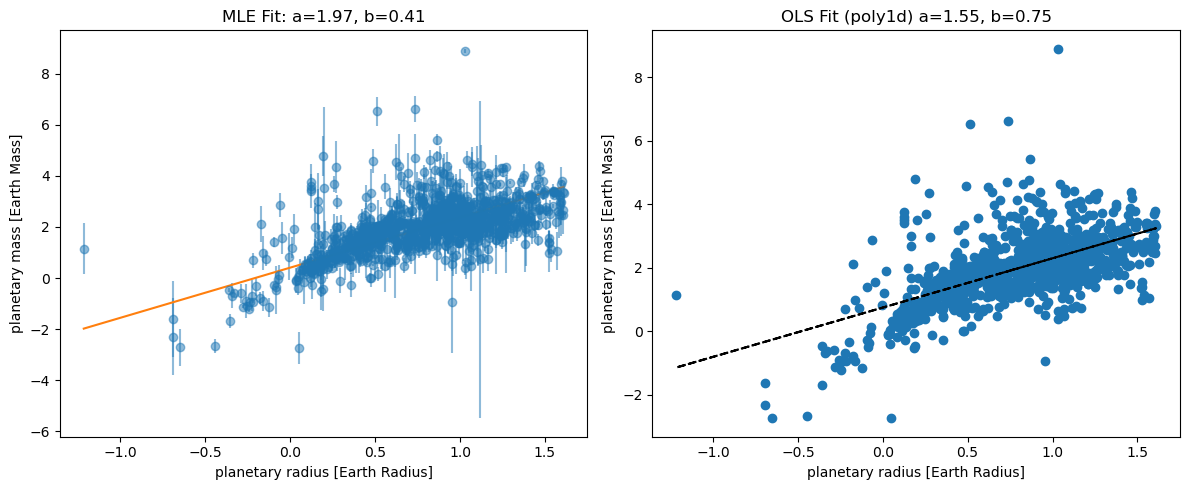

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Plot 1: mit Fehlerbalken + Fit
axs[0].errorbar(log_sample_b[:,0], log_sample_b[:,1], yerr=log_sample_b[:,2], fmt='o', alpha=0.5)
axs[0].plot(x_fit, y_fit)

axs[0].set_xlabel('planetary radius [Earth Radius]')
axs[0].set_ylabel('planetary mass [Earth Mass]')
axs[0].set_title(f"MLE Fit: a={a_3:.2f}, b={b_3:.2f}")


# 🔹 Plot 2: einfacher Fit (poly1d)
axs[1].plot(log_sample_b[:,0], log_sample_b[:,1], 'o')
axs[1].plot(log_sample_b[:,0], poly1d_fn(log_sample_b[:,0]), '--k')

axs[1].set_xlabel('planetary radius [Earth Radius]')
axs[1].set_ylabel('planetary mass [Earth Mass]')
axs[1].set_title(f"OLS Fit (poly1d) a={a:.2f}, b={b:.2f}")


plt.tight_layout()
plt.show()

In [72]:
def poly_model(x, a, b, c):
    return a+ b*x + c* (x**2) #+ 0*d* (x**3)

popt_poly, pcov_poly = curve_fit(
    poly_model,
    log_sample_a[:,0],
    log_sample_a[:,1],
    sigma=log_sample_a[:,2],
    absolute_sigma=True
)

a_poly, b_poly, c_poly = popt_poly

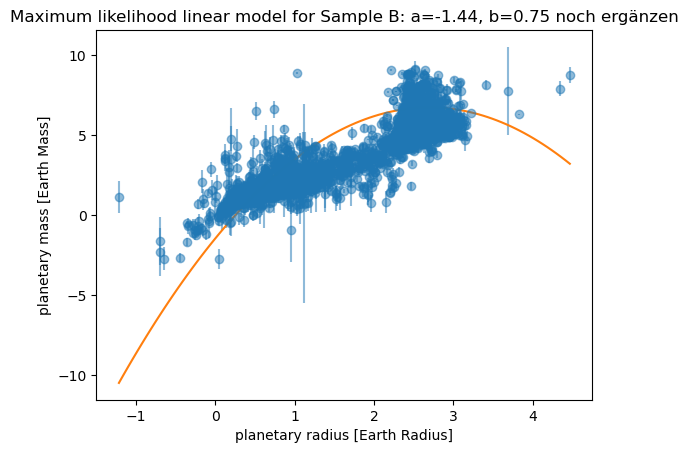

In [73]:
x_fit_poly = np.linspace(min(log_sample_a[:,0]), max(log_sample_a[:,0]), 100)
y_fit_poly = poly_model(x_fit_poly, a_poly, b_poly, c_poly)

plt.errorbar(log_sample_a[:,0], log_sample_a[:,1], yerr=log_sample_a[:,2], fmt='o', alpha=0.5)
plt.plot(x_fit_poly, y_fit_poly)

plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.title(f"Maximum likelihood linear model for Sample B: a={a_poly:.2f}, b={b:.2f} noch ergänzen")
plt.show()

Text(0, 0.5, 'planetary mass of solar planets [Earth Mass]')

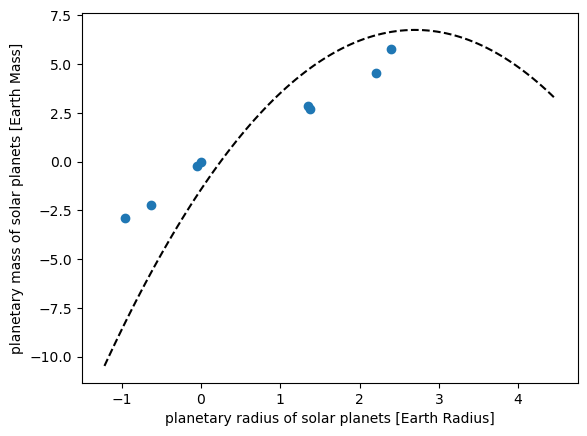

In [74]:
plt.plot(log_solarplanet_r,log_solarplanet_m,"o", x_fit_poly, y_fit_poly, '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius of solar planets [Earth Radius]')
plt.ylabel('planetary mass of solar planets [Earth Mass]')